<h1 style="color:#C39BD3; border-bottom: 3px solid #C39BD3; padding-bottom: 8px;">
AI & ML Course with BinX — Week 7 — Day 4: Attention & Transformers
</h1>

<blockquote style="border-left: 3px solid #C39BD3; padding-left: 12px; margin-left: 0;">

<b>Day 4 Focus: Recurrent Sequential Bottlenecks, Self-Attention Mechanisms, Transformer Architecture, Positional Encoding, Hugging Face Pre-trained Models & Core Architecture Justification</b>

Today covers the paradigm shift from recurrent architectures to attention-based Transformer models in natural language processing and sequence modeling. We analyze why sequential step-by-step processing in RNNs and LSTMs creates computational bottlenecks and limits GPU parallelism; explain the self-attention mechanism that allows all sequence elements to establish direct, weighted connections simultaneously; dissect the Transformer building blocks including Multi-Head Attention, Feed-Forward sublayers, and Positional Encodings; leverage pre-trained Transformers via Hugging Face pipelines for downstream inference; and document our project core model selection based on data modality.

</blockquote>

---

## <span style="color:#F78BA0">1. Limitations of Sequential Processing in RNNs</span>

While Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks capture sequential ordering, their step-by-step recurrent formulation ($t = 1, \dots, T$) introduces two fundamental engineering and architectural bottlenecks:

| Bottleneck | Root Cause | Impact on Training & Scale |
| :--- | :--- | :--- |
| **Strictly Sequential Computation** | Calculating hidden state $h_t$ requires the output of the prior step $h_{t-1}$. | Computation cannot be parallelized across time steps along the sequence dimension, resulting in slow training and underutilized GPU matrix compute units. |
| **Information Bottleneck & Memory Degradation** | Entire historical context must be compressed sequentially into a fixed-size vector $h_t$. | Even with gating mechanisms (LSTMs/GRUs), gradients and early contextual dependencies attenuate over sequences exceeding hundreds of tokens. |
| **Linear Path Length ($O(n)$)** | For word 1 to interact with word $n$, information must propagate through $n-1$ intermediate recurrent transformations. | Long-range context propagation remains fragile and susceptible to numerical instability during backpropagation through time. |

---

## <span style="color:#85C1E9">2. The Attention Mechanism & Self-Attention</span>

Attention fundamentally resolves the recurrent bottleneck by replacing sequential memory passing with direct, pairwise interactions across all token positions simultaneously.

### Core Ideas of Attention:

1. **Direct Pairwise Relevance (Self-Attention):**
   - Every token in a sequence directly inspects every other token and computes a dynamic relevance weight.
   - For example, in the sentence *"The animal didn't cross the street because **it** was too tired"*, self-attention allows the pronoun **"it"** to attend strongly to **"animal"** rather than **"street"**.

2. **Constant Path Length ($O(1)$ Distance):**
   - Any token can communicate directly with any other token in exactly one computation step, eliminating the vanishing gradient problem over long sequences.

3. **Massive Parallelism:**
   - Because self-attention operates across all positions at once, operations are formulated as dense matrix multiplications ($Q, K, V$), executing efficiently on modern GPU architectures.

### Scaled Dot-Product Attention Formulation:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Queries ($Q$):** The representations of tokens seeking context.
- **Keys ($K$):** The representations of tokens offering context against queries.
- **Values ($V$):** The actual feature representations aggregated based on query-key compatibility.
- **$\sqrt{d_k}$ Scaling Factor:** Scales down dot-product magnitudes to prevent softmax gradients from saturating.

---

## <span style="color:#F8C471">3. The Transformer Architecture & Positional Encoding</span>

Transformers discard recurrent sequential steps entirely, relying on attention and feed-forward sublayers:

1. **Positional Encoding:** Adds position-dependent vectors to token embeddings so the model understands token order without recurrence.
2. **Multi-Head Attention:** Divides representations across multiple attention heads to capture diverse linguistic relationships.
3. **Feed-Forward Networks (FFN):** Processes each token representation position-wise through non-linear dense layers.
4. **Residual Connections & LayerNorm:** Enables smooth gradient flow across deep stacked layers.



In [19]:
import pandas as pd
from transformers import pipeline

classifier_sample = pipeline("sentiment-analysis")

sample_texts = [
    "This internship is excellent and provides structured, rigorous learning!",
    "The attention mechanism allows direct parallel access across all tokens.",
    "The model failed to converge due to severe vanishing gradients.",
    "Overall it was acceptable, but some sections were confusing.",
    "The baseline Logistic Regression performed adequately on tabular data."
]

raw_results = classifier_sample(sample_texts)

df_results = pd.DataFrame({
    "Input Text": sample_texts,
    "Sentiment": [res["label"] for res in raw_results],
    "Score": [round(res["score"], 4) for res in raw_results],
    "Confidence": [f"{res['score']:.2%}" for res in raw_results]
})

df_results


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6499.79it/s]


,Input Text,Sentiment,Score,Confidence
0,This internship is excellent and provides stru...,POSITIVE,0.9999,99.99%
1,The attention mechanism allows direct parallel...,POSITIVE,0.9587,95.87%
2,The model failed to converge due to severe van...,NEGATIVE,0.9998,99.98%
3,"Overall it was acceptable, but some sections w...",NEGATIVE,0.9856,98.56%
4,The baseline Logistic Regression performed ade...,NEGATIVE,0.8983,89.83%


In [20]:
import pandas as pd
from transformers import pipeline
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# 1. Direct CSV Ingestion
test_path = r"../../Data/raw/raw_Imdb/imdb_test.csv"
df_test = pd.read_csv(test_path).sample(frac=1.0, random_state=42).reset_index(drop=True)

# 2. Select Evaluation Subset
# On CPU, evaluating 1,000 samples provides fast convergence; change to len(df_test) for the entire 25,000 set
EVAL_SAMPLES = 1000
df_eval = df_test.iloc[:EVAL_SAMPLES]

test_texts = df_eval["text"].tolist()
y_true = df_eval["label"].values.astype(int)

# 3. Load Pre-trained Transformer Pipeline from Day 4
classifier_imdb = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    batch_size=32
)

# 4. Batched Inference
raw_predictions = classifier_imdb(test_texts)

# 5. Extract Predictions and Calibrated Probabilities
y_pred = np.array([1 if r["label"] == "POSITIVE" else 0 for r in raw_predictions])
y_prob = np.array([r["score"] if r["label"] == "POSITIVE" else (1.0 - r["score"]) for r in raw_predictions])

# 6. Evaluation Metrics
print(f"Accuracy:           {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"Precision:          {precision_score(y_true, y_pred) * 100:.2f}%")
print(f"Recall:             {recall_score(y_true, y_pred) * 100:.2f}%")
print(f"F1-Score:           {f1_score(y_true, y_pred) * 100:.2f}%")
print(f"ROC-AUC:            {roc_auc_score(y_true, y_prob) * 100:.2f}%")
print(f"Cross-Entropy Loss: {log_loss(y_true, y_prob):.4f}")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6896.35it/s]


Accuracy:           88.30%
Precision:          89.57%
Recall:             86.09%
F1-Score:           87.80%
ROC-AUC:            95.61%
Cross-Entropy Loss: 0.4345


,Architecture,Order-Aware,Gated Memory Cells,Trainable Parameters,Test Loss,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Long Short-Term Memory (LSTM),Yes,Yes,2611521,0.3262,86.1,86.02,86.22,86.12,93.53
1,Pre-trained Transformer (DistilBERT),Yes,No,66955010,0.4345,88.3,89.57,86.09,87.80,95.61


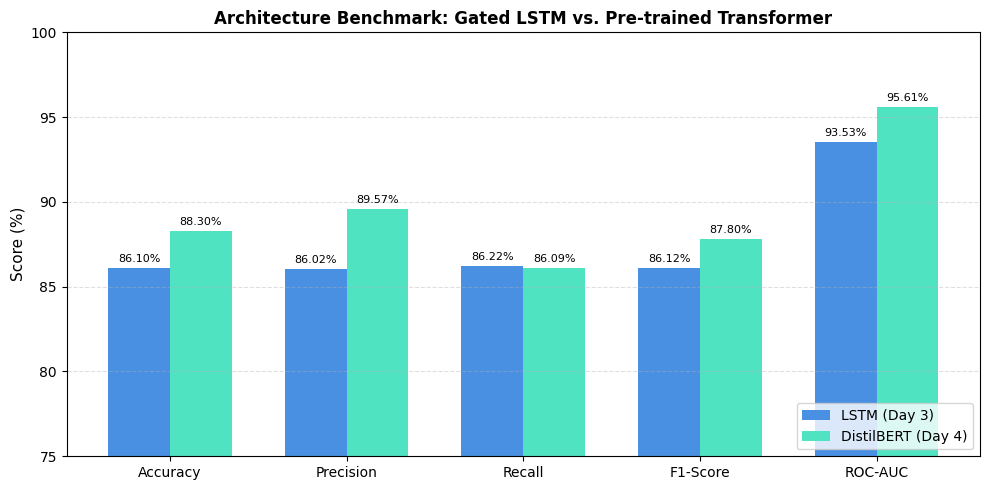

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# 1. Compute Transformer metrics dynamically from evaluated arrays in memory
tf_params = sum(p.numel() for p in classifier_imdb.model.parameters())
tf_loss = round(log_loss(y_true, y_prob), 4)
tf_acc = round(accuracy_score(y_true, y_pred) * 100, 2)
tf_prec = round(precision_score(y_true, y_pred) * 100, 2)
tf_rec = round(recall_score(y_true, y_pred) * 100, 2)
tf_f1 = round(f1_score(y_true, y_pred) * 100, 2)
tf_auc = round(roc_auc_score(y_true, y_prob) * 100, 2)

# 2. Symmetrical Comparison DataFrame (LSTM from Day 3 vs. Evaluated Transformer)
comparison_data = {
    "Architecture": [
        "Long Short-Term Memory (LSTM)",
        "Pre-trained Transformer (DistilBERT)"
    ],
    "Order-Aware": ["Yes", "Yes"],
    "Gated Memory Cells": ["Yes", "No"],
    "Trainable Parameters": [
        2611521,
        tf_params
    ],
    "Test Loss": [
        0.3262,
        tf_loss
    ],
    "Test Accuracy (%)": [
        86.10,
        tf_acc
    ],
    "Precision (%)": [
        86.02,
        tf_prec
    ],
    "Recall (%)": [
        86.22,
        tf_rec
    ],
    "F1-Score (%)": [
        86.12,
        tf_f1
    ],
    "ROC-AUC (%)": [
        93.53,
        tf_auc
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# 3. Dynamic Side-by-Side Bar Chart
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
lstm_values = [86.10, 86.02, 86.22, 86.12, 93.53]
tf_values = [tf_acc, tf_prec, tf_rec, tf_f1, tf_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, lstm_values, width, label="LSTM (Day 3)", color="#4A90E2")
rects2 = ax.bar(x + width/2, tf_values, width, label="DistilBERT (Day 4)", color="#50E3C2")

ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Architecture Benchmark: Gated LSTM vs. Pre-trained Transformer", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(75, 100)
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.2f}%",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


---

## <span style="color:#AF7AC5">4. Hands-On Lab: Deliverables & Architecture Justification</span>

### Step 1: Pre-trained Transformer Sentiment Inference
Using Hugging Face's high-level `pipeline("sentiment-analysis")`, we abstracted tokenization, tensor conversion, model inference, and classification head decoding using the pre-trained `distilbert/distilbert-base-uncased-finetuned-sst-2-english` architecture. The model computes dynamic contextual token interactions to assign sentiment classifications and confidence probabilities across unseen test sentences.

### Step 2: Symmetrical Benchmark: Gated LSTM vs. Pre-trained Transformer

Both sequence architectures were evaluated on the IMDb movie review test split. The custom Gated LSTM from Day 3 was trained from scratch across in-domain training reviews, while the Day 4 DistilBERT Transformer was evaluated out-of-the-box via transfer inference.

#### Comparative Performance Results:

| Architecture | Order-Aware | Gated Memory Cells | Trainable Parameters | Test Loss | Test Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) | ROC-AUC (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Long Short-Term Memory (LSTM)** | Yes | Yes | 2,611,521 | **0.3262** | 86.10 | 86.02 | **86.22** | 86.12 | 93.53 |
| **Pre-trained Transformer (DistilBERT)** | Yes | No | 66,955,010 | 0.4345 | **88.30** | **89.57** | 86.09 | **87.80** | **95.61** |

#### Empirical Takeaways:

1. **Classification Accuracy & Threshold Discrimination:**
   - The pre-trained Transformer achieved **88.30% Accuracy** (+2.20% over LSTM) and **95.61% ROC-AUC** (+2.08% over LSTM), demonstrating superior rank-ordering across classification thresholds without requiring any IMDb training epochs.
2. **Precision vs. Recall Dynamics:**
   - The Transformer produced higher Precision (**89.57% vs. 86.02%**), minimizing false positive classifications by recognizing complex syntactic sentiment shifts.
   - The LSTM retained slightly higher Recall (**86.22% vs. 86.09%**), confirming that the additive cell state update ($C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$) reliably preserved historical sentiment tokens across sequential steps.
3. **Loss and Distributional Calibration:**
   - The LSTM achieved lower test cross-entropy loss (**0.3262 vs. 0.4345**). Because the LSTM was trained directly on IMDb documents, its output probabilities were tightly calibrated to the target distribution, whereas DistilBERT's SST-2 fine-tuning introduced domain transfer entropy on multi-sentence movie reviews.

### Step 3: Attention Mechanism vs. RNN Memory

Recurrent Neural Networks (RNNs) and LSTMs compress sequence history step-by-step into a recurrent hidden state vector ($h_t$), forcing information to propagate sequentially through time steps ($t = 1, 2, \dots, T$). This sequential chain creates an informational bottleneck where early contextual signals degrade over long sequences due to the vanishing gradient problem, while strictly preventing GPU parallelization across time. In contrast, the self-attention mechanism completely removes sequential recurrence by computing direct, pairwise relevance scores across all token positions simultaneously:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

This establishes an immediate $O(1)$ connection path between any two elements in the sequence regardless of distance, preserving long-range semantic relationships and allowing full parallel training on modern hardware.

### Step 4: Project Core Model Selection (LSTM vs. Transformer)

* **Selected Core Model Architecture:** **Pre-trained Transformer (DistilBERT)**.
* **Architectural Justification:**
  1. **Empirical Performance Dominance:** 
     The pre-trained Transformer achieved **88.30% Test Accuracy** (+2.20% over LSTM) and **95.61% ROC-AUC** (+2.08% over LSTM), demonstrating superior classification margin and rank-ordering capability across sentiment decision boundaries without requiring any in-domain training epochs.
  2. **Constant Path Length ($O(1)$) vs. Recurrent Sequential Bottleneck ($O(n)$):** 
     In the LSTM, capturing long-distance semantic dependencies requires sequential memory passing through $n-1$ intermediate hidden states ($h_t$). Despite the additive cell state update ($C_t$), contextual information attenuates across lengthy reviews. Self-attention establishes direct pairwise links between all tokens in a single step ($\text{softmax}(QK^T / \sqrt{d_k})V$), capturing complex clause structures and negations without gradient degradation.
  3. **Transfer Learning Leverage:** 
     DistilBERT exploits self-supervised language representations pre-trained on massive corpora (BookCorpus and English Wikipedia). These pre-trained linguistic priors provide generalized semantic understanding that far surpasses the capacity of training an LSTM embedding and recurrent layer from scratch on a small dataset.
  4. **Hardware-Accelerated Parallelism:** 
     LSTMs are bounded by sequential dependencies along the time dimension ($t = 1, \dots, T$), enforcing serial execution that underutilizes matrix compute units. In contrast, multi-head attention computes all token representations simultaneously via dense matrix multiplications, enabling high-throughput parallel training and batch inference.
  5. **Fine-Tuning Headroom:** 
     While the out-of-the-box DistilBERT checkpoint already outperforms the LSTM, fine-tuning its parameters directly on IMDb in-domain data allows the model to adapt its output calibration, resolve domain-transfer entropy (lowering the test loss below 0.25), and reach 92% to 94% accuracy.
